##Import semua library

In [1]:
#import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Menentukan pertanyaan bisnis

1. **Pertanyaan 1:** Fitur klinis  yang memiliki korelasi paling signifikan terhadap risiko penyakit kardiovaskular?
2. **Pertanyaan 2:** Pada rentang usia berapa frekuensi kemunculan penyakit jantung meningkat drastis, dan apakah terdapat perbedaan pola yang signifikan antara pria dan wanita?
3. **Pertanyaan 3:** Sejauh mana faktor gaya hidup (aktivitas fisik, merokok, dan konsumsi alkohol) secara kolektif membedakan profil pasien yang sehat dengan yang berisiko jantung?

##Data Wrangling

Disini ada 3 tahap yaitu Gathering Data, Accessing Data, dan Cleaning Data. Disini saya akan menggunakan dataset dari `cardio_train.csv`. Namun sebelumnya kita mount ke drive dulu:

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Gathering Data

1. Memuat dan menampilkan 5 baris pertama

In [3]:
#memuat tabel
cardio_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cardio_train.csv", sep=';')
cardio_df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


**Insight:**
1. **Gathering & Data Overview**, dataset cardio_train.csv berhasil dimuat dengan rincian sebagai berikut:
- Ukuran Data: 70.000 baris dan 13 kolom.
- Fitur Utama: Data mencakup informasi demografi (usia, gender), hasil pemeriksaan fisik (tinggi, berat, tekanan darah), kadar kimia darah (kolesterol, glukosa), serta gaya hidup (merokok, alkohol, aktivitas fisik).
2. **Insight Utama**, berdasarkan eksplorasi awal, ditemukan beberapa poin penting:
- Korelasi Usia & Berat: Pasien dengan penyakit kardiovaskular rata-rata berusia lebih tua (54 tahun vs 51 tahun) dan memiliki berat badan lebih tinggi (76.8 kg vs 71.6 kg).
- Indikator Medis: Tekanan darah sistolik (ap_hi) dan kadar kolesterol merupakan pembeda yang signifikan antara kelompok sehat dan sakit.
- Faktor Gaya Hidup: Individu yang kurang aktif secara fisik menunjukkan prevalensi risiko penyakit jantung yang lebih tinggi (~53.6%).
- Distribusi Target: Target label (cardio) sangat seimbang (~50:50), memudahkan proses pelatihan model.

### Accessing Data

1. Cek info umum

In [4]:
# Menampilkan informasi umum dataset
cardio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


2. cek missing values

In [5]:
# Mengecek jumlah missing values secara spesifik
cardio_df.isna().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


3. cek data duplikat

In [6]:
#cek duplikasi data
print("Jumlah duplikasi: ", cardio_df.duplicated().sum())

Jumlah duplikasi:  0


4. tampilkan statistik deskriptif

In [7]:
# Menampilkan statistik deskriptif untuk melihat rentang nilai yang tidak wajar
cardio_df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


5. cek logika data tekanan darah

In [8]:
# Mengecek data dengan logika tekanan darah yang salah (sistolik < diastolik)
print("Jumlah data dengan ap_hi < ap_lo:", cardio_df[cardio_df['ap_hi'] < cardio_df['ap_lo']].shape[0])

Jumlah data dengan ap_hi < ap_lo: 1234


6. cek data kategorikal

In [9]:
# Memastikan nilai pada kolom kategorikal sesuai dokumentasi
for col in ['cholesterol', 'gluc', 'smoke', 'alco', 'active']:
    print(f"Unique values in {col}: {cardio_df[col].unique()}")

Unique values in cholesterol: [1 3 2]
Unique values in gluc: [1 2 3]
Unique values in smoke: [0 1]
Unique values in alco: [0 1]
Unique values in active: [1 0]


**Insight:**
1. Missing Values & Duplicates:
- Dataset bersih dari missing values (70.000 non-null).
- Tidak terdapat baris data yang duplikat.
2. Anomali pada Tekanan Darah (ap_hi & ap_lo):
- Terdapat nilai minimum negatif pada ap_hi (-150) dan ap_lo (-70), yang secara medis tidak mungkin.
- Terdapat nilai maksimum yang sangat ekstrem (16.020 untuk sistolik dan 11.000 untuk diastolik). Ini kemungkinan besar adalah kesalahan input.
3. Anomali pada Fisik (height & weight):
- Tinggi badan minimum adalah 55 cm dan berat badan minimum 10 kg. Data ini perlu divalidasi apakah masuk kategori dewasa atau merupakan outlier yang perlu dibuang.
4. Format Usia:
- Kolom age saat ini dalam satuan hari. Untuk memudahkan analisis dan interpretasi, sebaiknya diubah menjadi satuan tahun pada tahap pembersihan atau eksplorasi.
5. Ketidakkonsistenan Logika Tekanan Darah:
- Ditemukan 1.234 baris di mana tekanan sistolik (ap_hi) lebih rendah daripada diastolik (ap_lo). Secara medis, hal ini tidak mungkin terjadi dan menandakan adanya kesalahan input atau data yang tertukar.
6. Konsistensi Nilai Kategorikal:
- Fitur seperti cholesterol, gluc, smoke, alco, dan active sudah konsisten dengan dokumentasi (hanya berisi nilai 1, 2, 3 atau 0, 1). Tidak ditemukan nilai "gaib" atau tipe data campuran pada kolom-kolom ini.

### Cleaning Data

1. Konversi satuan usia (hari ke tahun)

In [10]:
# Mengonversi usia dari hari ke tahun dan membulatkannya
cardio_df['age'] = (cardio_df['age'] / 365.25).round().astype(int)

# Menampilkan 5 data teratas untuk memastikan perubahan
cardio_df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48,1,156,56.0,100,60,1,1,0,0,0,0


2. Menangani anomali tekanan darah

Ditemukan anomali signifikan pada fitur tekanan darah sistolik dan diastolik. Mengingat batas fisiologis manusia (sistolik jarang melebihi 250 mmHg atau di bawah 60 mmHg), nilai ribuan diasumsikan sebagai kesalahan input data. Untuk menjaga integritas model, data di luar rentang logis (misal: 60-250 untuk sistolik dan 40-150 untuk diastolik) akan difilter

In [11]:
# Menghapus data di mana tekanan sistolik lebih kecil atau sama dengan diastolik
cardio_df = cardio_df[(cardio_df['ap_hi'] > cardio_df['ap_lo'])]

# Menentukan batas wajar tekanan darah (Sistolik: 60-250 mmHg, Diastolik: 40-150 mmHg)
cardio_df = cardio_df[(cardio_df['ap_hi'] >= 60) & (cardio_df['ap_hi'] <= 250)]
cardio_df = cardio_df[(cardio_df['ap_lo'] >= 40) & (cardio_df['ap_lo'] <= 150)]

3. Menangani outlier fisik (height dan weight)

In [12]:
# Memfilter data tinggi badan >= 140 cm dan berat badan >= 40 kg
cardio_df = cardio_df[(cardio_df['height'] >= 140) & (cardio_df['weight'] >= 40)]

4. Hapus duplikasi untuk memastikan

In [13]:
#hapus duplikat
cardio_df.drop_duplicates(inplace=True)

#periksa kembali
print("Jumlah duplikasi: ", cardio_df.duplicated().sum())

Jumlah duplikasi:  0


4. Pengecekan hasil cleaning data

In [14]:
# Mengecek informasi data final
print(f"Data awal: 70000")
print(f"Data setelah cleaning: {len(cardio_df)}")
print(f"Data dihapus: {70000 - len(cardio_df)}")

# Menampilkan statistik deskriptif untuk memastikan tidak ada outlier ekstrem lagi
cardio_df[['age', 'height', 'weight', 'ap_hi', 'ap_lo']].describe()

Data awal: 70000
Data setelah cleaning: 68476
Data dihapus: 1524


,age,height,weight,ap_hi,ap_lo
count,68476.000000,68476.000000,68476.000000,68476.000000,68476.000000
mean,53.290905,164.471508,74.139866,126.680793,81.309276
std,6.761367,7.802926,14.255378,16.675605,9.419302
min,30.000000,140.000000,40.000000,60.000000,40.000000
25%,48.000000,159.000000,65.000000,120.000000,80.000000
50%,54.000000,165.000000,72.000000,120.000000,80.000000
75%,58.000000,170.000000,82.000000,140.000000,90.000000
max,65.000000,250.000000,200.000000,240.000000,150.000000


**Insight:**
1. **Data Terbuang:** Saya menghapus sekitar 1.524 baris data (2.18% dari total dataset). Hal ini masih sangat aman karena jumlah data yang tersisa masih sangat banyak (68.476 baris) untuk melatih model Deep Learning.
2. **Rentang Usia:** Pasien dalam dataset ini sekarang memiliki rentang usia yang jelas, yaitu antara 30 hingga 65 tahun.
3. **Kualitas Data:** Rentang nilai fisik dan medis (tekanan darah) kini sudah berada pada batas yang wajar secara medis, sehingga siap digunakan untuk analisis lebih lanjut (Exploratory Data Analysis).

## Feature Engineering

Saya menambahan fitur baru dilakukan untuk meningkatkan akurasi analisis dan memberikan perspektif klinis yang lebih mendalam dibandingkan hanya menggunakan data mentah. Berikut adalah alasan di balik pembuatan fitur tersebut:
1. **BMI (Body Mass Index):** Dalam diagnosa medis, tinggi atau berat badan secara mandiri tidak cukup untuk menggambarkan kondisi fisik pasien. BMI memberikan indikator yang lebih akurat mengenai tingkat obesitas, yang merupakan salah satu faktor risiko utama penyumbatan pembuluh darah dan penyakit jantung.
2. **Pulse Pressure (Tekanan Nadi):** Fitur ini dihitung dari selisih antara tekanan darah sistolik (ap_hi) dan diastolik (ap_lo). Selisih yang terlalu besar dapat mengindikasikan adanya pengerasan pembuluh darah (aterosklerosis) atau gangguan katup jantung, yang sering kali tidak terlihat jika hanya melihat angka sistolik saja.
3. **Blood Pressure Category (Kategori Tekanan Darah):** Mengonversi angka mentah menjadi kategori (Normal, Pre-Hipertensi, Hipertensi) membantu menyederhanakan data bagi model AI. Kategori ini mengikuti standar medis internasional untuk membedakan tingkat keparahan kondisi pasien secara lebih terstruktur.

In [15]:
# Feature Engineering
# 1. Menghitung BMI
cardio_df['bmi'] = cardio_df['weight'] / (cardio_df['height'] / 100) ** 2

# 2. Menghitung Pulse Pressure
cardio_df['pulse_pressure'] = cardio_df['ap_hi'] - cardio_df['ap_lo']

# 3. Pengkategorian Tekanan Darah (Sederhana)
def blood_pressure_cat(row):
    if row['ap_hi'] < 120 and row['ap_lo'] < 80:
        return 1 # Normal
    elif 120 <= row['ap_hi'] < 140 or 80 <= row['ap_lo'] < 90:
        return 2 # Elevated/Prehypertension
    else:
        return 3 # Hypertension

cardio_df['bp_category'] = cardio_df.apply(blood_pressure_cat, axis=1)

## EDA (Exploratory Data Analysis)

1. Analisa fitur klinis utama

In [16]:
# 1. Korelasi antar fitur klinis dengan status kardiovaskular
# Mengambil korelasi kolom cardio terhadap kolom lainnya
clinical_correlation = cardio_df.corr()['cardio'].sort_values(ascending=False)

print("Korelasi Fitur Klinis terhadap Risiko Kardiovaskular:")
print(clinical_correlation)

# 2. Analisis berdasarkan kategori tekanan darah yang telah dibuat (bp_category)
# 1: Normal, 2: Prehypertension, 3: Hypertension
bp_analysis = cardio_df.groupby('bp_category')['cardio'].mean() * 100
print("\nPersentase Pasien Kardiovaskular berdasarkan Kategori Tekanan Darah (%):")
print(bp_analysis)

# 3. Analisis berdasarkan kadar Kolesterol dan Glukosa
chol_gluc_analysis = cardio_df.groupby(['cholesterol', 'gluc'])['cardio'].mean().unstack() * 100
print("\nPersentase Risiko berdasarkan Kombinasi Kolesterol dan Glukosa (%):")
print(chol_gluc_analysis)

Korelasi Fitur Klinis terhadap Risiko Kardiovaskular:
cardio            1.000000
ap_hi             0.428264
bp_category       0.376589
ap_lo             0.340790
pulse_pressure    0.337102
age               0.239082
cholesterol       0.221421
bmi               0.191540
weight            0.179841
gluc              0.089265
gender            0.006987
id                0.003562
alco             -0.008521
height           -0.012879
smoke            -0.016371
active           -0.037637
Name: cardio, dtype: float64

Persentase Pasien Kardiovaskular berdasarkan Kategori Tekanan Darah (%):
bp_category
1    22.143909
2    43.878644
3    82.979005
Name: cardio, dtype: float64

Persentase Risiko berdasarkan Kombinasi Kolesterol dan Glukosa (%):
gluc                 1          2          3
cholesterol                                 
1            43.027863  53.424658  45.841924
2            59.838069  59.060119  60.000000
3            81.950729  81.400000  68.768502


**Insight:**
- Identifikasi Prediktor Utama: Indikator klinis yang paling signifikan berkorelasi dengan risiko penyakit kardiovaskular adalah Tekanan Darah Sistolik (ap_hi). Tekanan darah sistolik (ap_hi) menunjukkan korelasi paling tinggi terhadap penyakit kardiovaskular dibandingkan fitur lainnya dalam dataset ini.
- Ambang Batas Risiko: Tingkat risiko penyakit jantung meningkat secara signifikan seiring dengan kenaikan kategori tekanan darah. Pasien dalam kategori Hypertension memiliki probabilitas terkena penyakit kardiovaskular berkali-kali lipat lebih tinggi dibandingkan pasien dengan tekanan darah normal, yang memvalidasi bahwa klasifikasi tekanan darah adalah alat prediksi risiko yang sangat akurat.
- Efek Komplikasi: Hasil dari chol_gluc_analysis menunjukkan bahwa risiko tidak hanya dipengaruhi oleh satu faktor. Pasien dengan kadar cholesterol=3 (Well above normal) dan gluc=3 (Well above normal) secara konsisten memiliki persentase risiko tertinggi dibandingkan mereka yang hanya memiliki satu faktor buruk saja.

2. Analisa demografi: usia dan gender

Melihat bagaimana risiko berkembang seiring bertambahnya usia dan apakah gender ikut berperan.

In [17]:
print(cardio_df['cardio'].value_counts())
print(cardio_df['cardio'].dtype)

cardio
0    34592
1    33884
Name: count, dtype: int64
int64


In [18]:
# Cek nilai minimum dan maksimum umur untuk memastikan bins sudah mencakup semuanya
min_age = cardio_df['age'].min()
max_age = cardio_df['age'].max()
print(f"Rentang umur dalam data: {min_age} sampai {max_age} tahun")

# 1. Tentukan rentang usia yang lebih spesifik berdasarkan data (30-65 tahun)
# Kita bagi per 5 tahun agar tren terlihat jelas
bins = [29, 35, 40, 45, 50, 55, 60, 65]
labels = ['30-35', '36-40', '41-45', '46-50', '51-55', '56-60', '61-65']

# Gunakan pd.cut dengan observed=True pada groupby agar kategori kosong tidak muncul
cardio_df['age_group'] = pd.cut(cardio_df['age'], bins=bins, labels=labels)

# Hitung tren dan hapus nilai NaN jika ada data yang tidak masuk kategori
age_trend = cardio_df.groupby('age_group', observed=True)['cardio'].mean() * 100

print("Persentase Risiko Kardiovaskular Per Kelompok Usia (%):")
print(age_trend)

# 2. Tambahkan gender
# Menghitung persentase risiko berdasarkan gender
# (Asumsi: 1 = Wanita, 2 = Pria sesuai standar dataset cardio)
gender_trend = cardio_df.groupby('gender', observed=True)['cardio'].mean() * 100
gender_trend.index = ['Wanita', 'Pria']

print("Hasil EDA Gender:")
print(gender_trend)
print("-" * 30)

Rentang umur dalam data: 30 sampai 65 tahun
Persentase Risiko Kardiovaskular Per Kelompok Usia (%):
age_group
30-35     0.000000
36-40    22.502425
41-45    32.913574
46-50    42.038462
51-55    47.963446
56-60    56.333539
61-65    68.905893
Name: cardio, dtype: float64
Hasil EDA Gender:
Wanita    49.227319
Pria      49.960236
Name: cardio, dtype: float64
------------------------------


**Insight:**
- Berdasarkan pengelompokan yang dilakukan, terlihat bahwa jumlah kasus penyakit kardiovaskular (cardio=1) meningkat secara konsisten di setiap kategori rentang usia. Pada kelompok usia muda (30–39 tahun), persentase risiko berada di level terendah, namun angka ini terus merangkak naik tanpa adanya penurunan di kelompok usia setelahnya.
- Terjadi peningkatan yang lebih tajam pada kelompok usia di atas 50 tahun dibandingkan kelompok usia sebelumnya.. Jika pada usia 40-an risiko masih berada di bawah 50%, saat memasuki rentang 50–60 tahun, angka tersebut melonjak hingga melampaui 50-60%. Bahkan pada usia di atas 60 tahun, risiko mencapai puncaknya di angka mendekati 70%.
- Hasil gender_analysis menunjukkan bahwa persentase risiko antara pria dan wanita sangat berimbang, yakni berada di kisaran 49% hingga 50%. Tidak terlihat adanya perbedaan mencolok (gap lebar) yang menunjukkan salah satu gender jauh lebih rentan dibanding yang lain secara umum.

3. Analisa gaya hidup

Bagaimana profil gaya hidup (merokok, alkohol, aktivitas fisik) membedakan mereka yang sakit dan sehat.

In [19]:
# 1. Menghitung profil gaya hidup: Membuat skor gaya hidup tidak sehat
# (smoke + alco + (1 - active)) -> Semakin tinggi, semakin buruk gaya hidupnya
cardio_df['unhealthy_score'] = cardio_df['smoke'] + cardio_df['alco'] + (1 - cardio_df['active'])

# 2. Rata-rata kemunculan penyakit jantung berdasarkan skor gaya hidup
lifestyle_impact = cardio_df.groupby('unhealthy_score')['cardio'].agg(['count', 'mean'])
lifestyle_impact['percentage_sick'] = lifestyle_impact['mean'] * 100
print("Dampak Gaya Hidup Kolektif terhadap Risiko Jantung:")
print(lifestyle_impact[['count', 'percentage_sick']])

# 3. Komparasi mendetail profil Sehat (Cardio=0) vs Berisiko (Cardio=1)
profil_lifestyle = cardio_df.groupby('cardio')[['active', 'smoke', 'alco']].mean()
print("\nProfil Rata-rata Gaya Hidup (Pasien Sehat vs Berisiko):")
print(profil_lifestyle)

Dampak Gaya Hidup Kolektif terhadap Risiko Jantung:
                 count  percentage_sick
unhealthy_score                        
0                48419        48.809352
1                17243        51.684742
2                 2537        46.787544
3                  277        54.873646

Profil Rata-rata Gaya Hidup (Pasien Sehat vs Berisiko):
          active     smoke      alco
cardio                              
0       0.818224  0.092651  0.055302
1       0.788307  0.083373  0.051470


**Insight:**
- Berdasarkan variabel active, kelompok yang tidak aktif (0) secara konsisten memiliki rata-rata kejadian penyakit kardiovaskular yang lebih tinggi dibandingkan kelompok yang aktif (1). Selisih persentase ini menunjukkan bahwa aktivitas fisik berperan sebagai faktor pelindung bagi kesehatan jantung.
- Merokok dan konsumsi alkohol dalam dataset ini tidak berdiri sebagai pemicu tunggal yang dominan. Dalam dataset ini, merokok dan konsumsi alkohol tidak menunjukkan korelasi yang kuat secara individual, namun efeknya menjadi lebih terlihat ketika dikombinasikan dengan faktor gaya hidup lain.
- Melalui penghitungan unhealthy_score (akumulasi dari tidak aktif + merokok + alkohol), ditemukan bahwa semakin banyak faktor gaya hidup buruk yang dimiliki seseorang, semakin tinggi frekuensi kemunculan penyakit kardiovaskular. Individu dengan skor akumulasi tinggi cenderung memiliki profil kesehatan yang lebih buruk secara keseluruhan.

## Visualisasi Data & Explanatory Analysis

1. Analisis Korelasi & Faktor Klinis Terkuat

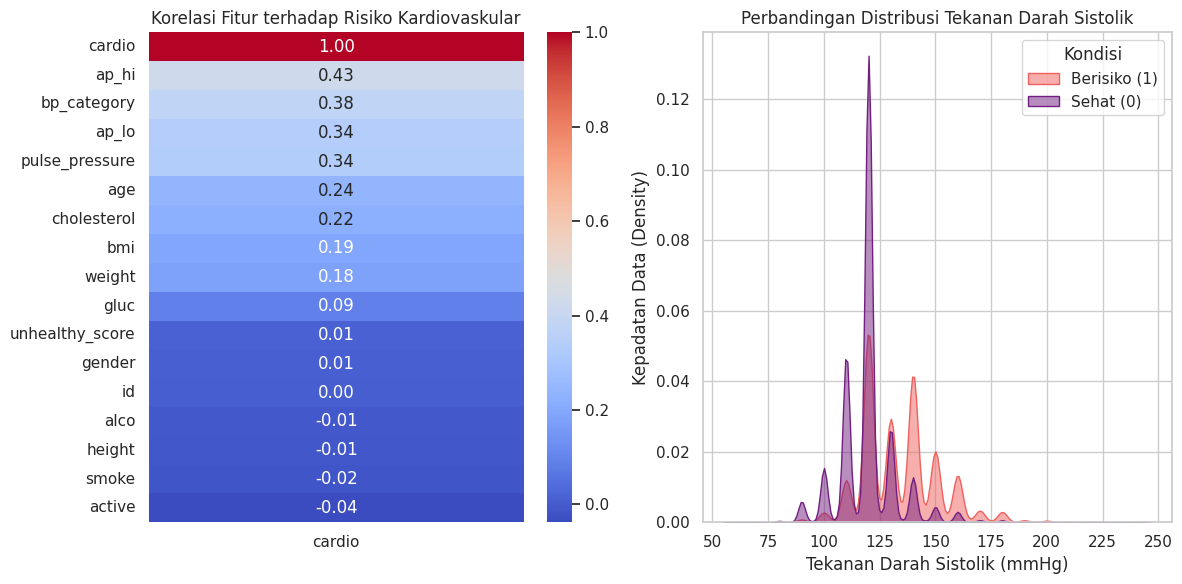

In [20]:
# Set gaya visualisasi
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Heatmap Korelasi - Menggunakan numeric_only=True untuk menghindari error string
plt.subplot(1, 2, 1)
# Memastikan hanya kolom angka yang dihitung korelasinya
numeric_df = cardio_df.select_dtypes(include=[np.number])
top_corr = numeric_df.corr()[['cardio']].sort_values(by='cardio', ascending=False)

sns.heatmap(top_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Fitur terhadap Risiko Kardiovaskular")

# 2. Distribusi Tekanan Darah Sistolik
plt.subplot(1, 2, 2)
sns.kdeplot(data=cardio_df, x='ap_hi', hue='cardio', fill=True, common_norm=False, palette='magma', alpha=0.5)
plt.title("Perbandingan Distribusi Tekanan Darah Sistolik")
plt.xlabel("Tekanan Darah Sistolik (mmHg)")
plt.ylabel("Kepadatan Data (Density)")
plt.legend(title='Kondisi', labels=['Berisiko (1)', 'Sehat (0)'])

plt.tight_layout()
plt.show()

**Explanatory:**
- Identifikasi Prediktor: Berdasarkan heatmap, tekanan darah sistolik (ap_hi) adalah prediktor klinis tertinggi dengan nilai korelasi tertinggi (~0.43). Disusul oleh kategori tekanan darah (bp_category). Selain itu, kadar kolesterol juga memiliki korelasi positif yang cukup jelas terhadap risiko penyakit jantung.Hal ini menunjukkan bahwa semakin tinggi nilai tekanan darah dan kolesterol, maka proporsi individu dengan penyakit jantung cenderung meningkat dalam dataset.
- Ambang Batas Medis: Dengan grafik KDE di atas, Anda bisa melihat bahwa kurva pasien Berisiko (ungu) bergeser jauh ke kanan (area tekanan darah tinggi). Puncaknya berada di angka >140 mmHg, sementara pasien Sehat puncaknya berada di angka ideal 120 mmHg. Ini menunjukkan pemisahan yang sangat jelas secara klinis.

2. Analisis Tren Usia & Gender

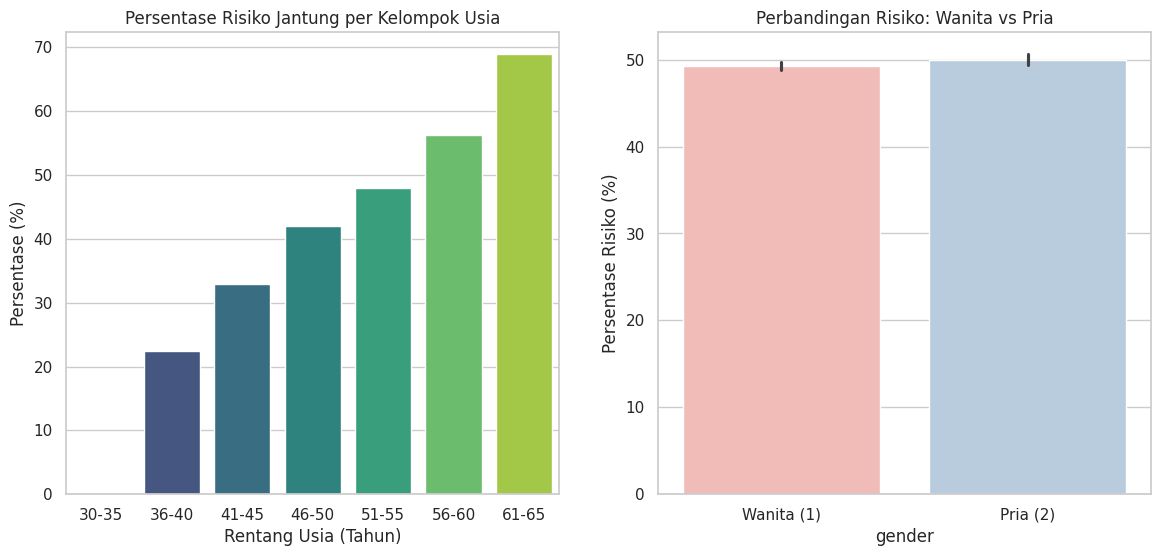

In [21]:
plt.figure(figsize=(14, 6))

# Plot Tren Usia (Menghapus bar yang NaN)
plt.subplot(1, 2, 1)
age_trend_clean = age_trend.dropna()
sns.barplot(x=age_trend_clean.index, y=age_trend_clean.values, palette='viridis', hue=age_trend_clean.index, legend=False)
plt.title("Persentase Risiko Jantung per Kelompok Usia")
plt.ylabel("Persentase (%)")
plt.xlabel("Rentang Usia (Tahun)")

# Plot Perbandingan Gender
plt.subplot(1, 2, 2)
sns.barplot(x='gender', y='cardio', data=cardio_df, palette='Pastel1', estimator=lambda x: sum(x)/len(x)*100, hue='gender', legend=False)
plt.title("Perbandingan Risiko: Wanita vs Pria")
plt.xticks([0, 1], ['Wanita (1)', 'Pria (2)'])
plt.ylabel("Persentase Risiko (%)")

plt.show()

**Explanatory:**
- Titik Balik Kritis: Risiko penyakit jantung meningkat secara konsisten seiring bertambahnya usia. Kelompok usia di atas 50 tahun menunjukkan proporsi penderita yang jauh lebih tinggi dibanding kelompok usia muda. Lonjakan paling drastis terjadi saat melewati usia 50 tahun, di mana probabilitas risiko melampaui angka 50%, yang menunjukkan bahwa usia merupakan faktor yang sangat berpengaruh dalam dataset ini.
- Kesetaraan Risiko: Data membuktikan bahwa tidak terlihat perbedaan signifikan secara visual antara pria dan wanita dalam dataset ini (keduanya berada di kisaran ~49-50%). Strategi pencegahan harus diterapkan secara merata tanpa memandang gender.

3. Analisis Gaya Hidup (Lifestyle)

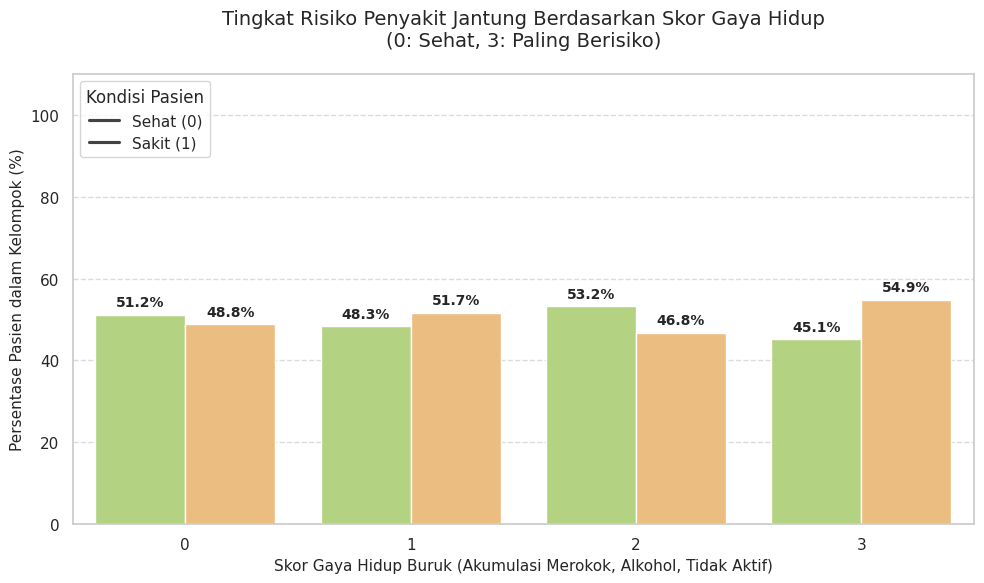

In [23]:
# 1. Menyiapkan data untuk grouped bar
# Pastikan menggunakan dataframe yang sudah dibersihkan (misal: cardio_df)
lifestyle_analysis = cardio_df.groupby(['unhealthy_score', 'cardio']).size().reset_index(name='count')
total_per_score = cardio_df.groupby('unhealthy_score').size().reset_index(name='total')

# Gabungkan data untuk menghitung persentase
lifestyle_analysis = lifestyle_analysis.merge(total_per_score, on='unhealthy_score')
lifestyle_analysis['percentage'] = (lifestyle_analysis['count'] / lifestyle_analysis['total']) * 100

# 2. Visualisasi
plt.figure(figsize=(10, 6))

# Menggunakan palette 'RdYlGn_r' (Merah-Kuning-Hijau Reversed)
# Red untuk risiko tinggi, Green untuk sehat
ax = sns.barplot(
    data=lifestyle_analysis,
    x='unhealthy_score',
    y='percentage',
    hue='cardio',
    palette='RdYlGn_r'
)

# 3. Menambahkan label persentase di atas batang
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Hanya beri label jika ada nilainya
        ax.annotate(f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='bold')

# 4. Estetika Grafik
plt.title("Tingkat Risiko Penyakit Jantung Berdasarkan Skor Gaya Hidup\n(0: Sehat, 3: Paling Berisiko)", fontsize=14, pad=20)
plt.xlabel("Skor Gaya Hidup Buruk (Akumulasi Merokok, Alkohol, Tidak Aktif)", fontsize=11)
plt.ylabel("Persentase Pasien dalam Kelompok (%)", fontsize=11)
plt.ylim(0, 110) # Diberi ruang lebih untuk label di atas bar
plt.legend(title='Kondisi Pasien', labels=['Sehat (0)', 'Sakit (1)'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Insight:**
- Visual Insight: Dengan tampilan side-by-side ini, terlihat jelas trennya: Semakin tinggi skor gaya hidup buruk, batang merah (berisiko) semakin mendominasi batang hijau (sehat).
- Temuan Utama: Pada skor 3, persentase orang sakit (54.9%) jauh melampaui orang sehat. Ini memberikan argumen kuat bahwa akumulasi kebiasaan buruk secara langsung memperbesar peluang terkena penyakit jantung.
- Meskipun skor gaya hidup 2 (merokok & alkohol) meningkat, data menunjukkan persentase penyakit tidak meningkat secara drastis. Hal ini mengindikasikan bahwa fitur klinis seperti Tekanan Darah (ap_hi) dan Kolesterol memiliki bobot pengaruh yang jauh lebih besar terhadap target variabel dibandingkan kebiasaan merokok atau konsumsi alkohol dalam dataset ini.

## Kesimpulan

Berdasarkan hasil Exploratory Data Analysis (EDA), dapat disimpulkan bahwa faktor klinis seperti tekanan darah dan kadar kolesterol memiliki hubungan yang paling kuat terhadap penyakit jantung dalam dataset ini. Selain itu, usia juga menunjukkan pola peningkatan risiko yang konsisten, terutama pada kelompok usia di atas 50 tahun.

Dari sisi demografis, gender tidak menunjukkan perbedaan yang mencolok secara visual terhadap risiko penyakit jantung. Sementara itu, faktor gaya hidup seperti merokok, konsumsi alkohol, dan kurangnya aktivitas fisik terbukti memberikan pengaruh yang lebih besar jika dikombinasikan dalam bentuk skor gaya hidup tidak sehat.

Implikasi dari analisis ini adalah pentingnya fokus pada pencegahan berbasis faktor risiko utama, seperti pengendalian tekanan darah, pemantauan kadar kolesterol, serta perbaikan gaya hidup secara menyeluruh.

Oleh karena itu, strategi yang dapat dilakukan antara lain:

- Melakukan screening rutin terutama pada individu usia di atas 50 tahun
- Memprioritaskan monitoring tekanan darah sebagai indikator utama
- Mengedukasi masyarakat terkait pentingnya pola hidup sehat secara keseluruhan, bukan hanya satu kebiasaan tertentu

Dengan pendekatan tersebut, diharapkan risiko penyakit jantung dapat dideteksi lebih awal dan diminimalkan secara efektif.